Question 4: Higher-dimensional data with a conditional INN


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset


In [2]:

# Set device and seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Helper to get one-hot encoding
def get_one_hot(labels, num_classes=10):
    return torch.nn.functional.one_hot(labels.long(), num_classes).float()

# 4. Conditional Coupling Layer
class ConditionalCouplingLayer(nn.Module):
    def __init__(self, input_size, hidden_size, mask, condition_size):
        super().__init__()
        self.register_buffer('mask', mask)
        
        # Network now accepts input + condition
        self.nested_net = nn.Sequential(
            nn.Linear(input_size + condition_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2 * input_size) # Outputs t and s
        )

    def forward(self, x, c):
        m = self.mask
        x_frozen = x * m
        
        # Concatenate condition c to the frozen input
        net_input = torch.cat((x_frozen, c), dim=1)
        
        h = self.nested_net(net_input)
        t, s = torch.chunk(h, 2, dim=-1)
        
        s = torch.tanh(s)
        scale = torch.exp(s)
        
        # Affine coupling
        x_active = x * (1 - m)
        y = x_frozen + (x_active * scale + (1 - m) * t)
        
        log_det = torch.sum((1 - m) * s, dim=-1)
        
        return y, log_det

    def inverse(self, y, c):
        m = self.mask
        y_frozen = y * m
        
        # Concatenate condition for inverse pass
        net_input = torch.cat((y_frozen, c), dim=1)
        
        h = self.nested_net(net_input)
        t, s = torch.chunk(h, 2, dim=-1)
        
        s = torch.tanh(s)
        scale = torch.exp(s)
        
        y_active = y * (1 - m)
        
        # Inverse affine transformation
        x = y_frozen + (y_active - (1 - m) * t) / scale
        log_det = -torch.sum((1 - m) * s, dim=-1)
        
        return x, log_det



In [3]:
# Conditional RealNVP Model
class ConditionalRealNVP(nn.Module):
    def __init__(self, input_size=64, hidden_size=128, blocks=8, condition_size=10):
        super().__init__()
        self.blocks = blocks
        self.layers = nn.ModuleList()
        
        # Create coupling layers with alternating masks
        for i in range(blocks):
            mask = (torch.arange(input_size) % 2 == (i % 2)).float()
            self.layers.append(
                ConditionalCouplingLayer(input_size, hidden_size, mask, condition_size)
            )
            
    def forward(self, x, c):
        log_det_total = torch.zeros(x.size(0), device=x.device)
        y = x
        
        for layer in self.layers:
            y, log_det = layer(y, c)
            log_det_total += log_det
            
        return y, log_det_total

    def inverse(self, y, c):
        log_det_total = torch.zeros(y.size(0), device=y.device)
        x = y
        
        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x, c)
            log_det_total += log_det
            
        return x, log_det_total

    def sample(self, num_samples, c):
        z = torch.randn(num_samples, 64).to(c.device)
        x_gen, _ = self.inverse(z, c)
        return x_gen

# Loss function
def nll_loss(z, log_det):
    log_pz = -0.5 * torch.sum(z**2, dim=1) - 0.5 * z.shape[1] * np.log(2 * np.pi)
    log_px = log_pz + log_det
    return -torch.mean(log_px)

# Training loop
def train_conditional(X, y, hidden_size=256, blocks=8, batch_size=64, lr=1e-3, epochs=50):
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = ConditionalRealNVP(input_size=64, hidden_size=hidden_size, blocks=blocks, condition_size=10).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    print(f"Training Conditional INN for {epochs} epochs...")
    
    for ep in range(epochs):
        model.train()
        batch_loss = []
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            
            z, log_det = model(bx, by)
            loss = nll_loss(z, log_det)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_loss.append(loss.item())
            
        if (ep + 1) % 10 == 0:
            print(f"Epoch [{ep+1}/{epochs}], Loss: {np.mean(batch_loss):.4f}")
            
    return model



Training Conditional INN for 60 epochs...
Epoch [10/60], Loss: -29.1877
Epoch [20/60], Loss: -46.8522
Epoch [30/60], Loss: -53.2268
Epoch [40/60], Loss: -66.3236
Epoch [50/60], Loss: -69.2302
Epoch [60/60], Loss: -71.4523


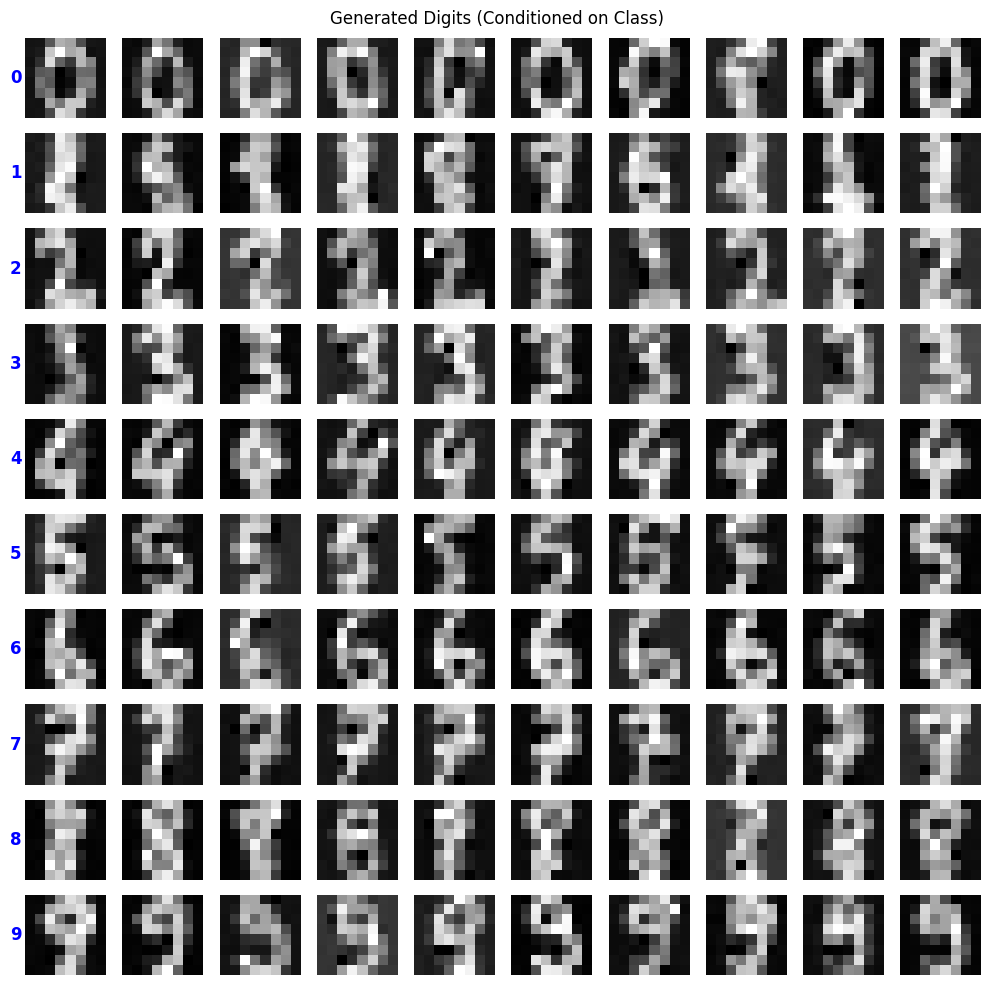


Checking generation quality with Random Forest...
RF Accuracy on Test Set: 0.9722
RF Accuracy on Generated Data: 0.8970
RF Mean Confidence on Generated Data: 0.6927


In [4]:
# --- Main ---

# 1. Load and prepare MNIST digits
digits = load_digits()
X_raw = digits.data.astype(np.float32)
y_raw = digits.target
X_norm = (X_raw - X_raw.mean()) / X_raw.std()

X_train, X_test, y_train, y_test = train_test_split(X_norm, y_raw, test_size=0.2, random_state=seed)

X_train_t = torch.tensor(X_train)
y_train_oh = get_one_hot(torch.tensor(y_train))

# 2. Train the model
model = train_conditional(X_train_t, y_train_oh, hidden_size=512, blocks=8, epochs=60, batch_size=128)

# 3. Generate samples conditioned on labels 0-9
model.eval()
labels_gen = torch.arange(10).repeat_interleave(10) # Generate 10 examples per digit
y_gen_oh = get_one_hot(labels_gen).to(device)

with torch.no_grad():
    x_gen = model.sample(num_samples=len(labels_gen), c=y_gen_oh)
    x_gen_np = x_gen.cpu().numpy()

# Plot generated digits
plt.figure(figsize=(10, 10))
for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(x_gen_np[i].reshape(8, 8), cmap='gray')
    plt.axis('off')
    if i % 10 == 0:
        plt.text(-2, 4, str(i // 10), fontsize=12, fontweight='bold', color='blue')
plt.suptitle("Generated Digits (Conditioned on Class)")
plt.tight_layout()
plt.show()

# 4. Evaluation using Random Forest Classifier
print("\nChecking generation quality with Random Forest...")

# Train RF on real data
rf = RandomForestClassifier(n_estimators=100, random_state=seed)
rf.fit(X_train, y_train)

# Check RF baseline accuracy
y_pred_real = rf.predict(X_test)
print(f"RF Accuracy on Test Set: {accuracy_score(y_test, y_pred_real):.4f}")

# Check accuracy on synthetic data
n_eval = 1000
y_eval_lbl = torch.randint(0, 10, (n_eval,))
y_eval_oh = get_one_hot(y_eval_lbl).to(device)

with torch.no_grad():
    x_eval = model.sample(n_eval, y_eval_oh).cpu().numpy()

y_pred_gen = rf.predict(x_eval)
acc_gen = accuracy_score(y_eval_lbl.numpy(), y_pred_gen)
probs_gen = rf.predict_proba(x_eval)
conf_gen = np.max(probs_gen, axis=1).mean()

print(f"RF Accuracy on Generated Data: {acc_gen:.4f}")
print(f"RF Mean Confidence on Generated Data: {conf_gen:.4f}")